<h1>Smart MCQ Solver Challenge</h1>

<h2>About the Competition</h2>
<p>
The Smart MCQ Solver Challenge aims to develop intelligent AI and machine learning systems capable of solving complex multiple-choice questions. Each question consists of a prompt and five answer options labeled A, B, C, D, and E. Participants must predict the top three most likely correct answers in ranked order.
</p>

<h2>Objective</h2>
<p>
The goal of this competition is to build models that can understand context, perform reasoning, and effectively rank answer choices. Participants are encouraged to explore transformer-based architectures, retrieval-augmented generation (RAG), fine-tuned language models, ensemble methods, and efficient inference techniques to maximize performance.
</p>

<h2>Dataset Description</h2>

<table border="1" cellpadding="8" cellspacing="0">
    <thead>
        <tr>
            <th>Column</th>
            <th>Data Type</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>id</td>
            <td>int64</td>
            <td>Unique identifier for each question.</td>
        </tr>
        <tr>
            <td>prompt</td>
            <td>object</td>
            <td>The multiple-choice question or prompt.</td>
        </tr>
        <tr>
            <td>A</td>
            <td>object</td>
            <td>Answer option A.</td>
        </tr>
        <tr>
            <td>B</td>
            <td>object</td>
            <td>Answer option B.</td>
        </tr>
        <tr>
            <td>C</td>
            <td>object</td>
            <td>Answer option C.</td>
        </tr>
        <tr>
            <td>D</td>
            <td>object</td>
            <td>Answer option D.</td>
        </tr>
        <tr>
            <td>E</td>
            <td>object</td>
            <td>Answer option E.</td>
        </tr>
        <tr>
            <td>answer</td>
            <td>object</td>
            <td>Correct answer label (A, B, C, D, or E).</td>
        </tr>
    </tbody>
</table>

## Models Notebook 

NOTE: All working notebook have been shared with only **dlgenaiproject**.

<div> <span>Deployment Link:</span> : <a href="https://huggingface.co/spaces/chndra/23f3001092">https://huggingface.co/spaces/chndra/23f3001092</a> </div>


* **Bilstm + RAG(notebook):** <a href="https://www.kaggle.com/code/chandra24208/scrach-bilstm">RAG BILSTM Notebook Link</a>      <h3>Leaderboard score <bold>0.76600</bold></h3>

* **Bert-base-uncased(notebook):** <a href="https://www.kaggle.com/code/chandra24208/bert-base-uncased">Bert Notebook Link</a>   <h3>Leaderboard score <bold>0.75716</bold></h3>

* **Logistic Regression(notebook):** <a href="https://www.kaggle.com/code/chandra24208/scrach-lr">LR Notebook Link</a> <h3>Leaderboard score <bold>0.7510</bold></h3>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')


## Dataset Loading & Exploration

In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print('Loaded')

Loaded


In [4]:
train_df.head(3)

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [5]:
test_df.head(3)

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...


In [6]:
print(f"Train Dataset Shape: {train_df.shape} | Test Dataset Shape: {test_df.shape}")

Train Dataset Shape: (2000, 8) | Test Dataset Shape: (500, 7)


In [7]:
print(f"Train_df Columns: {train_df.columns.to_list()}")
print(" ")
print(f"Test_df Columns: {test_df.columns.to_list()}")

Train_df Columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
 
Test_df Columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


In [8]:
train_df.isna().sum()
# print('No NaN Values Present in Any Col')

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [9]:
test_df.isna().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

In [10]:
train_df.dropna(inplace=True)

In [11]:
test_df.dropna(inplace=True)

In [12]:
test_df.drop_duplicates(inplace=True)

In [13]:
train_df.drop_duplicates(inplace=True)

In [14]:
print(f"Train Dataset Shape: {train_df.shape} | Test Dataset Shape: {test_df.shape}")

Train Dataset Shape: (2000, 8) | Test Dataset Shape: (500, 7)


In [15]:
print(train_df['id'].duplicated().sum())
print(" ")
print(test_df['id'].duplicated().sum())

0
 
0


In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [17]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


In [18]:
train_df['answer'].value_counts(normalize=True)*100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

## Exploratory Data Analysis (EDA)

We explore the train and test data before modeling.
Extra length features are created here **only for plots** — they do not go into ML/DL.


### EDA 1 — Answer distribution

How often each option (A–E) is the correct answer.

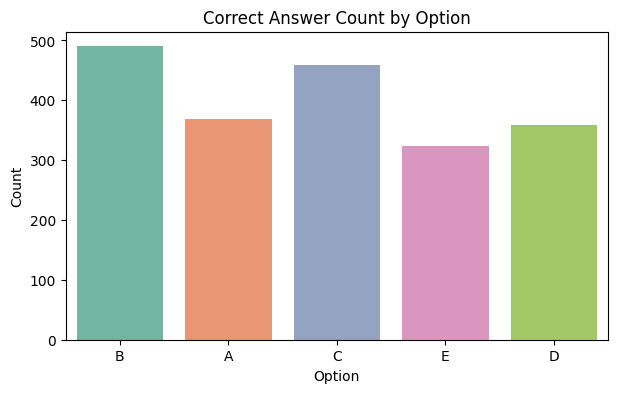

In [19]:
# Chart: count of correct answers per option
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
sns.countplot(x=train_df['answer'], palette='Set2')
plt.title('Correct Answer Count by Option')
plt.xlabel('Option')
plt.ylabel('Count')
plt.show()


### EDA 2 — Prompt length

Character length of each question prompt.

In [20]:
# How long are the prompts? (characters)
train_df['prompt_len'] = train_df['prompt'].str.len()
test_df['prompt_len']  = test_df['prompt'].str.len()

train_df['prompt_len'].describe()


count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_len, dtype: float64

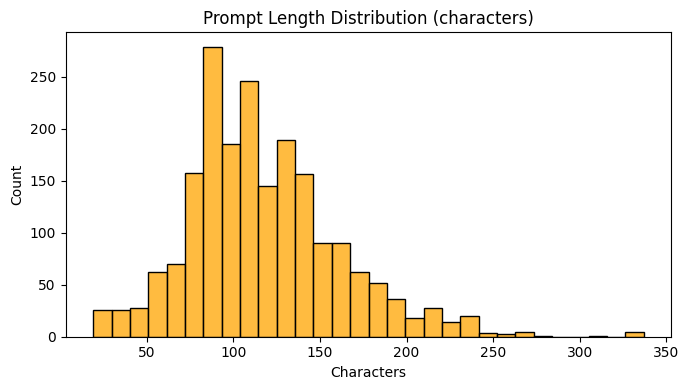

In [21]:
# Chart: histogram of prompt lengths
plt.figure(figsize=(7, 4))
sns.histplot(train_df['prompt_len'], color='orange', bins=30)
plt.title('Prompt Length Distribution (characters)')
plt.xlabel('Characters')
plt.tight_layout()
plt.show()


### EDA 3 — Option lengths

Length of each answer choice (A, B, C, D, E).

In [22]:
# Length of each option column
for col in ['A', 'B', 'C', 'D', 'E']:
    train_df[f'{col}_len'] = train_df[col].str.len()
    test_df[f'{col}_len']  = test_df[col].str.len()


In [23]:
# Summary stats per option length
len_cols = ['A_len', 'B_len', 'C_len', 'D_len', 'E_len']
train_df[len_cols].describe()


,A_len,B_len,C_len,D_len,E_len
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


### EDA 4 — Derived length features

Average, min, max, and range of option lengths per question.

In [24]:
# One row per question: average / min / max option length
train_df['avg_option_len']   = train_df[len_cols].mean(axis=1)
test_df['avg_option_len']    = test_df[len_cols].mean(axis=1)
train_df['max_option_len']   = train_df[len_cols].max(axis=1)
test_df['max_option_len']    = test_df[len_cols].max(axis=1)
train_df['min_option_len']   = train_df[len_cols].min(axis=1)
test_df['min_option_len']    = test_df[len_cols].min(axis=1)
train_df['option_len_range'] = train_df['max_option_len'] - train_df['min_option_len']
test_df['option_len_range']  = test_df['max_option_len'] - test_df['min_option_len']


In [25]:
# Word count in each prompt
train_df['prompt_word_count'] = train_df['prompt'].str.split().str.len()
test_df['prompt_word_count']  = test_df['prompt'].str.split().str.len()


### EDA 5 — Extra simple charts

Quick visual checks on text length patterns.

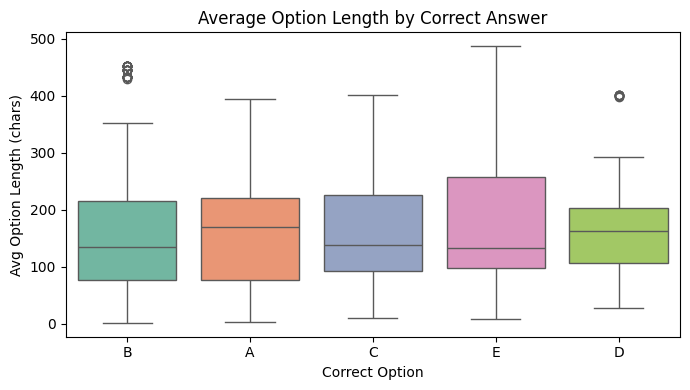

In [26]:
# Chart 1: average option length vs correct answer
plt.figure(figsize=(7, 4))
sns.boxplot(x='answer', y='avg_option_len', data=train_df, palette='Set2')
plt.title('Average Option Length by Correct Answer')
plt.xlabel('Correct Option')
plt.ylabel('Avg Option Length (chars)')
plt.tight_layout()
plt.show()


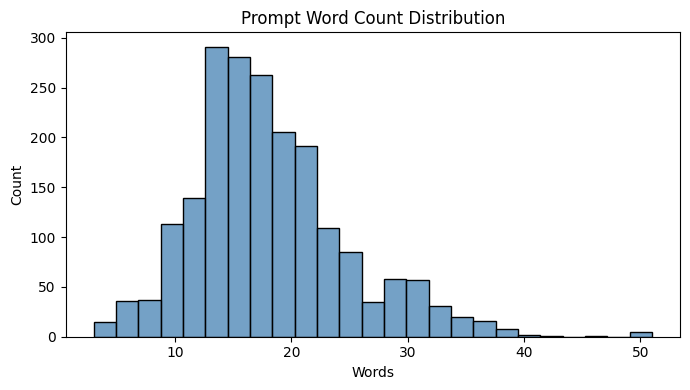

In [27]:
# Chart 2: prompt word count distribution
plt.figure(figsize=(7, 4))
sns.histplot(train_df['prompt_word_count'], color='steelblue', bins=25)
plt.title('Prompt Word Count Distribution')
plt.xlabel('Words')
plt.tight_layout()
plt.show()


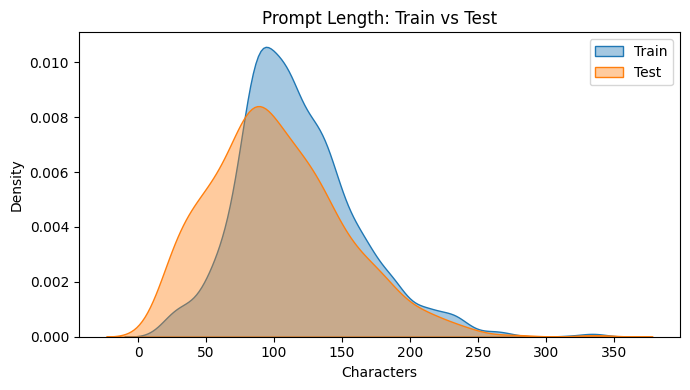

In [28]:
# Chart 3: train vs test prompt length (are they similar?)
plt.figure(figsize=(7, 4))
sns.kdeplot(train_df['prompt_len'], label='Train', fill=True, alpha=0.4)
sns.kdeplot(test_df['prompt_len'],  label='Test',  fill=True, alpha=0.4)
plt.title('Prompt Length: Train vs Test')
plt.xlabel('Characters')
plt.legend()
plt.tight_layout()
plt.show()


### EDA 6 — Correlation heatmap

How length features relate to each other.

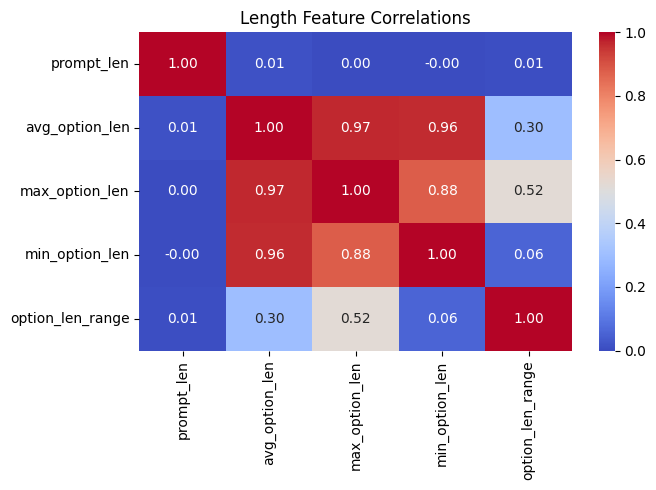

In [29]:
# Correlation between numeric length features
num_cols = [
    'prompt_len',
    'avg_option_len',
    'max_option_len',
    'min_option_len',
    'option_len_range',
]

plt.figure(figsize=(7, 5))
sns.heatmap(train_df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Length Feature Correlations')
plt.tight_layout()
plt.show()


## Modeling Data Preparation

`train_df` / `test_df` already have EDA features.
For ML and DL we copy only the original competition columns into new variables:
`df_train` and `df_test`.


In [30]:
# Clean copies for modeling (no EDA-only columns)
df_train = train_df[['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']].copy()
df_test  = test_df[['id', 'prompt', 'A', 'B', 'C', 'D', 'E']].copy()

print('df_train:', df_train.shape)
print('df_test :', df_test.shape)
df_train.head(2)


df_train: (2000, 8)
df_test : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A


## Feature Engineering (Pairwise Ranking Format)

MCQ ranking idea:
- Each question has 5 options: A, B, C, D, E
- Convert each question into **5 rows** (one row per option)
- Model learns a score for each option
- Top-3 scores become the prediction


In [31]:
OPTION_COLS = ['A', 'B', 'C', 'D', 'E']
print(OPTION_COLS)


['A', 'B', 'C', 'D', 'E']


In [32]:
def get_option_tail(row):
    """Find where options start to differ, return the differing 'tail' text."""
    opts = [str(row[c]) for c in OPTION_COLS]
    min_len = min(len(o) for o in opts)

    div = 0
    for i in range(min_len):
        chars_at_i = set(o[i] for o in opts)
        if len(chars_at_i) > 1:
            div = i
            break

    tails = {c: o[div:] for c, o in zip(OPTION_COLS, opts)}
    return tails, div


# Quick check
sample_tails, sample_div = get_option_tail(df_train.iloc[0])
print('div_point:', sample_div)
print({k: v[:40] for k, v in sample_tails.items()})


div_point: 17
{'A': 'believes that humans exist within a time', 'B': 'believes that humans do not exist inside', 'C': 'does not believe in the existence of tim', 'D': 'believes that the relationship between t', 'E': 'believes that time is an illusion, and t'}


In [33]:
def make_pairwise(df, is_train=True):
    """Convert question-level rows into option-level pairwise rows."""
    rows = []

    for _, r in df.iterrows():
        tails, div = get_option_tail(r)
        prompt = str(r['prompt'])
        p_words = set(re.findall(r'\b\w{4,}\b', prompt.lower()))

        opt_lens = [len(str(r[c])) for c in OPTION_COLS]
        avg_len = np.mean(opt_lens) + 1e-6

        all_words = set()
        for c in OPTION_COLS:
            all_words |= set(re.findall(r'\b\w{4,}\b', str(r[c]).lower()))

        for j, c in enumerate(OPTION_COLS):
            option_text = str(r[c])
            o_words = set(re.findall(r'\b\w{4,}\b', option_text.lower()))
            t_words = set(re.findall(r'\b\w{4,}\b', tails[c].lower()))

            label = 0
            if is_train and r['answer'] == c:
                label = 1

            rows.append({
                'qid': r['id'],
                'option': c,
                'text_full': prompt + ' [ANS] ' + option_text,
                'text_tail': tails[c],
                'rel_len': opt_lens[j] / avg_len,
                'overlap': len(p_words & o_words) / max(len(p_words), 1),
                'tail_overlap': len(p_words & t_words) / max(len(p_words), 1),
                'unique_ratio': len(o_words - (all_words - o_words)) / max(len(o_words), 1),
                'div_point': div,
                'tail_len_ratio': len(tails[c]) / max(len(option_text), 1),
                'label': label,
            })

    return pd.DataFrame(rows)


In [34]:
print('Building pairwise train...')
pw_train = make_pairwise(df_train, is_train=True)
print('pw_train:', pw_train.shape)


Building pairwise train...
pw_train: (10000, 11)


In [35]:
print('Building pairwise test...')
pw_test = make_pairwise(df_test, is_train=False)
print('pw_test:', pw_test.shape)


Building pairwise test...
pw_test: (2500, 11)


In [36]:
pw_train.head(6)


,qid,option,text_full,text_tail,rel_len,overlap,tail_overlap,unique_ratio,div_point,tail_len_ratio,label
0,1,A,Pick the best possible answer: What is Martin ...,believes that humans exist within a time conti...,1.300847,0.2500,0.1250,1.0,17,0.944625,0
1,1,B,Pick the best possible answer: What is Martin ...,"believes that humans do not exist inside time,...",1.093220,0.2500,0.1250,1.0,17,0.934109,1
2,1,C,Pick the best possible answer: What is Martin ...,does not believe in the existence of time or t...,0.940678,0.3750,0.2500,1.0,17,0.923423,0
3,1,D,Pick the best possible answer: What is Martin ...,believes that the relationship between time an...,0.855932,0.4375,0.3125,1.0,17,0.915842,0
4,1,E,Pick the best possible answer: What is Martin ...,"believes that time is an illusion, and the pas...",0.809322,0.1875,0.0625,1.0,17,0.910995,0
5,2,A,What is accelerator-based light-ion fusion? [A...,light-ion fusion reactions. This method is rel...,1.041026,0.8000,0.4000,1.0,140,0.655172,1


## TF-IDF Vectorization

We build two text features:
1. **Word TF-IDF** on `text_full` (prompt + option)
2. **Char TF-IDF** on `text_tail` (differentiating suffix)

Then we stack them with small numeric features.


In [37]:
tfidf_word = TfidfVectorizer(
    max_features=60000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    analyzer='word',
)

tfidf_char = TfidfVectorizer(
    max_features=40000,
    ngram_range=(2, 5),
    sublinear_tf=True,
    min_df=1,
    analyzer='char_wb',
)


In [38]:
Xw_tr  = tfidf_word.fit_transform(pw_train['text_full'])
Xw_tst = tfidf_word.transform(pw_test['text_full'])

Xc_tr  = tfidf_char.fit_transform(pw_train['text_tail'])
Xc_tst = tfidf_char.transform(pw_test['text_tail'])

print('Word TF-IDF:', Xw_tr.shape)
print('Char TF-IDF:', Xc_tr.shape)


Word TF-IDF: (10000, 13091)
Char TF-IDF: (10000, 22082)


In [39]:
num_feats = [
    'rel_len',
    'overlap',
    'tail_overlap',
    'unique_ratio',
    'div_point',
    'tail_len_ratio',
]

X_num_tr  = csr_matrix(pw_train[num_feats].values.astype(float))
X_num_tst = csr_matrix(pw_test[num_feats].values.astype(float))

X_tr  = hstack([Xw_tr, Xc_tr, X_num_tr])
X_tst = hstack([Xw_tst, Xc_tst, X_num_tst])
y_tr  = pw_train['label'].values

print('Full train matrix:', X_tr.shape)
print('Positive labels  :', int(y_tr.sum()), '/', len(y_tr))


Full train matrix: (10000, 35179)
Positive labels  : 2000 / 10000


## Evaluation Metric: MAP@3

For each question we submit top-3 options.
Score is Average Precision at k=3, then mean over questions.


In [40]:
def apk(actual, predicted, k=3):
    score = 0.0
    hits = 0
    for i, p in enumerate(predicted[:k]):
        if p == actual:
            hits += 1
            score += hits / (i + 1.0)
    return score


def mapk(actuals, preds, k=3):
    return float(np.mean([apk(a, p, k) for a, p in zip(actuals, preds)]))


def rank_preds(pw, scores, orig_df):
    """Convert option-level scores into top-3 option lists per question."""
    pw = pw.copy()
    pw['score'] = scores
    preds = []
    for qid in orig_df['id']:
        q = pw[pw['qid'] == qid].sort_values('score', ascending=False)
        preds.append(q['option'].tolist()[:3])
    return preds


print('MAP@3 check:', apk('A', ['A', 'B', 'C']))


MAP@3 check: 1.0


## Model 1 — Logistic Regression

Uses GroupKFold so that all 5 options of the same question stay in the same fold.


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=2000, C=8.0, n_jobs=-1)

lr.fit(X_tr, y_tr)

LogisticRegression(C=8.0, max_iter=2000, n_jobs=-1)

In [42]:
oof_lr = lr.predict_proba(X_tr)[:, 1]
tst_lr = lr.predict_proba(X_tst)[:, 1]

In [43]:
# Training Accuracy 
train_acc = accuracy_score(y_tr, (oof_lr > 0.5).astype(int))
print(f'Train Accuracy: {train_acc:.4f}')

#map@3
lr_map3 = mapk(df_train['answer'].tolist(), rank_preds(pw_train, oof_lr, df_train))
print(f'LR MAP@3: {lr_map3:.4f}')

Train Accuracy: 0.9943
LR MAP@3: 0.9952


## Model 2 — LightGBM

Same feature matrix and same GroupKFold splits as Logistic Regression.


## Model 3 & 4 — Deep Learning (BiLSTM + BERT)

Both models score each MCQ option (pairwise rows), using **`bert-base-uncased`'s `AutoTokenizer`** for both models — no custom `Dataset` class, no hand-built vocabulary.

**Test submission uses BiLSTM only.** BERT is trained for comparison.


### Preparing DL text data

We reuse the same pairwise rows from feature engineering.
Each row = one option with its full text and label (1 = correct).


In [44]:
# Keeping columns needed for deep learnin
dl_train = pw_train[['qid', 'option', 'text_full', 'label']].rename(columns={'text_full': 'text'}).copy()
dl_test  = pw_test[['qid', 'option', 'text_full']].rename(columns={'text_full': 'text'}).copy()

print('dl_train:', dl_train.shape)
print('dl_test :', dl_test.shape)
dl_train.head(3)


dl_train: (10000, 4)
dl_test : (2500, 3)


,qid,option,text,label
0,1,A,Pick the best possible answer: What is Martin ...,0
1,1,B,Pick the best possible answer: What is Martin ...,1
2,1,C,Pick the best possible answer: What is Martin ...,0


### Tokenize with AutoTokenizer (bert-base-uncased)

One tokenizer builds `input_ids` + `attention_mask` tensors for **both** BiLSTM and BERT — no `Counter`, no `word2id`, no custom `Dataset` class.


In [45]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME, MAX_LEN, BATCH_SIZE = 'bert-base-uncased', 128, 16
print('Device:', device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    enc = tokenizer(list(texts), max_length=MAX_LEN, truncation=True, padding='max_length', return_tensors='pt')
    return enc['input_ids'], enc['attention_mask']

train_ids, train_mask = encode(dl_train['text'])
test_ids, test_mask   = encode(dl_test['text'])
labels = torch.tensor(dl_train['label'].values, dtype=torch.float32)


Device: cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Train/validation split + `TensorDataset`  `DataLoader`

A single 80/20 split by `qid` (all 5 options of a question stay together). Tensors go straight into `TensorDataset` — shared by BiLSTM and BERT.


In [46]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_i, va_i = next(gss.split(dl_train, groups=dl_train['qid']))

train_loader = DataLoader(TensorDataset(train_ids[tr_i], train_mask[tr_i], labels[tr_i]), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(train_ids[va_i], train_mask[va_i], labels[va_i]), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_ids, test_mask), batch_size=BATCH_SIZE, shuffle=False)

def predict(model, loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch[0].to(device), batch[1].to(device)
            scores.extend(torch.sigmoid(model(ids, mask)).cpu().numpy())
    return np.array(scores)

va_pw   = dl_train.iloc[va_i].reset_index(drop=True)
va_orig = df_train[df_train['id'].isin(va_pw['qid'].unique())]


### Step 4 — BiLSTM model

`input_ids` → **Embedding** → **BiLSTM** → **Linear** head (one score per option).


In [47]:
import torch
import torch.nn as nn

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, input_ids, attention_mask=None):

        emb = self.dropout(self.embedding(input_ids))
        
        
        lstm_out, _ = self.lstm(emb)
        
        
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float() 
            
            masked_out = lstm_out * mask
            
            pooled = masked_out.sum(dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)
        else:
            pooled = lstm_out.mean(dim=1)
            
        output = self.fc(self.dropout(pooled))
        return output.squeeze(1)

bilstm = BiLSTM(tokenizer.vocab_size).to(device)
print('BiLSTM ready')

BiLSTM ready


### Step 5 — Train BiLSTM

A training loop: forward pass, BCE loss, backward, step.


In [48]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(bilstm.parameters(), lr=1e-3, weight_decay=0.01)

# Training Loop with Epoch Loss Tracking
for epoch in range(5):
    bilstm.train()
    total_loss = 0.0
    
    for ids, mask, y in train_loader:
        ids, mask, y = ids.to(device), mask.to(device), y.to(device)
        optimizer.zero_grad()
        
        # Explicitly pass attention_mask
        preds = bilstm(ids, attention_mask=mask)
        loss = criterion(preds, y.float())
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(bilstm.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch + 1}/5 | Average Loss: {avg_loss:.4f}')

Epoch 1/5 | Average Loss: 0.5145
Epoch 2/5 | Average Loss: 0.4389
Epoch 3/5 | Average Loss: 0.3218
Epoch 4/5 | Average Loss: 0.2318
Epoch 5/5 | Average Loss: 0.1894


### Step 6 — BiLSTM validation MAP@3 & test predictions

Score the validation split for MAP@3, then score the test set for submission.


In [49]:
bilstm_map3 = mapk(va_orig['answer'].tolist(), rank_preds(va_pw, predict(bilstm, val_loader), va_orig))
tst_bilstm  = predict(bilstm, test_loader)

print(f'BiLSTM MAP@3: {bilstm_map3:.4f}')


BiLSTM MAP@3: 0.9583


### Step 7 — BERT (`bert-base-uncased`)

bert pretrained fintuned model

In [50]:
class BertRanker(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)

    def forward(self, input_ids, attention_mask):
        return self.bert(input_ids=input_ids, attention_mask=attention_mask).logits.squeeze(1)

bert_model = BertRanker().to(device)
print('BertRanker ready')


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertRanker ready


### Step 8 — Train BERT

Fine-tune for a couple of epochs with `AdamW` — same loop shape as BiLSTM.


In [51]:
bert_optimizer = AdamW(bert_model.parameters(), lr=2e-5)

for epoch in range(2):
    bert_model.train()
    for ids, mask, y in train_loader:
        ids, mask, y = ids.to(device), mask.to(device), y.to(device)
        bert_optimizer.zero_grad() 
        loss = criterion(bert_model(ids, mask), y)
        loss.backward()
        bert_optimizer.step()
    print(f'Epoch {epoch + 1}/2  loss={loss.item():.4f}')


Epoch 1/2  loss=0.3882
Epoch 2/2  loss=0.3226


### Step 9 — BERT validation MAP@3


In [52]:
bert_map3 = mapk(va_orig['answer'].tolist(), rank_preds(va_pw, predict(bert_model, val_loader), va_orig))
print(f'BERT MAP@3: {bert_map3:.4f}')


BERT MAP@3: 0.9671


## Final Ensemble

Test submission uses Bert scores only.

Model comparison:
1. Logistic Regression
2. LightGBM
3. BiLSTM 
4. BERT 


In [53]:
print('Model MAP@3 (validation)')
print(f'  LR     : {lr_map3:.4f}')
print(f'  BiLSTM : {bilstm_map3:.4f}')
print(f'  BERT   : {bert_map3:.4f}')


Model MAP@3 (validation)
  LR     : 0.9952
  BiLSTM : 0.9583
  BERT   : 0.9671


## Submission


In [54]:
tst_bert = predict(bert_model, test_loader)

test_top3 = rank_preds(pw_test, tst_bert, df_test)

submission = pd.DataFrame({
    'ID': df_test['id'],
    'Prediction': [' '.join(p) for p in test_top3],
})

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')
submission.head(10)

Saved submission.csv


,ID,Prediction
0,1,A B E
1,2,B D A
2,3,B E A
3,4,E C A
4,5,C D B
5,6,D C A
6,7,E C B
7,8,B A C
8,9,C D E
9,10,B E C
